## Telemetry-Based Remaining Useful Life (RUL) Prediction
### Predictive Maintenance on NASA CMAPSS Dataset

### Objective
-The goal of this project is to predict the Remaining Useful Life (RUL) of aircraft engines using sensor data. This helps in understanding engine degradation and enables predictive maintenance.

#### Approach
-We analyze sensor behavior, select important features, and build a machine learning model to estimate RUL.


→ Each column of the data set is "<space>" separated, So when we encounter a single space or    multiple we make that To be a column. header is taken as None, To NOT consider the first row of the dataset as the column name.


In [66]:
import pandas as pd

data = pd.read_csv("E:\Data Science Project\Telemetry Anomaly\Telemetry Dataset - CMaps/train_FD001.txt", sep=r"\s+", header= None) 
data

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [65]:
data = pd.read_csv("cleaned_data.csv")

In [ ]:
data.columns


Index(['unit', 'cycle', 'operational setting 1', 'operational setting 2',
       'operational setting 3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4',
       'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
       'sensor_21'],
      dtype='str')

### Data Cleaning


→ Cleaning the dataset and making it workable.

In [ ]:
#  Renaming the columns.
new_columns_name = []
for i in data.columns:
    column_name = input(f"Enter the name for column {i}: ")
    new_columns_name.append(column_name if column_name else i )
new_columns_name 

for i in range(5, len(new_columns_name)):
    new_columns_name[i] = f"sensor_{i-4}"
    data.columns = new_columns_name
data                                   

In [2]:
# Checking for Missing Values, if any.
data.isna().sum()
data.duplicated().value_counts()
data.isna().value_counts()

unit   cycle  operational setting 1  operational setting 2  operational setting 3  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  sensor_7  sensor_8  sensor_9  sensor_10  sensor_11  sensor_12  sensor_13  sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21
False  False  False                  False                  False                  False     False     False     False     False     False     False     False     False     False      False      False      False      False      False      False      False      False      False      False      False        20631
Name: count, dtype: int64

Storing the cleaned data.

In [ ]:
data.to_csv("cleaned_data.csv", index=False)

Working on individual units 

-- We first perform Operations on a single unit, to study and analyze the trend of the sensors data

In [67]:
import pandas as pd 
data_train = pd.read_csv("cleaned_data.csv")
data = data_train

→Working on Individual engine units. Studying and Analyzing sensor nature

In [68]:
engine_1 = data[data["unit"]==1]
engine_1

,unit,cycle,operational setting 1,operational setting 2,operational setting 3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,519.79,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,519.58,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,520.04,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,519.57,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295


In [69]:
engine_1.columns



Index(['unit', 'cycle', 'operational setting 1', 'operational setting 2',
       'operational setting 3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4',
       'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
       'sensor_21'],
      dtype='str')

#### Exploratory Data Analysis

We inspect sensor trends for individual engine units to understand:
- which sensors vary over time
- which sensors stay nearly constant
- which sensors may reflect degradation


Visualizing how the individual sensors are changing

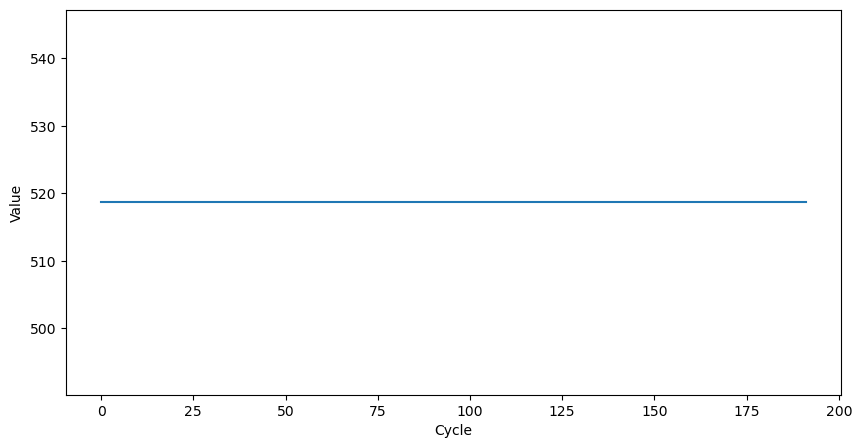

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(engine_1["sensor_1"])
plt.xlabel("Cycle")
plt.ylabel("Value")
plt.show()

#  This sensor is constant.

In [71]:
# Separating out sensor Features from the dataset
sensors_only = []
for i in engine_1.columns[5:]:
    sensors_only.append(i)
sensors_only

['sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21']

#### Normalizing the sensor values and then plotting them

→ If visualizing sensors with different scale of values(some very large , some very small),<br>
      on the same plot.To be able to view their variations, they must be Scaled Into a common Scale.

In [72]:
from sklearn.preprocessing import MinMaxScaler

scaled = MinMaxScaler().fit_transform(engine_1[sensors_only])
scaled_df = pd.DataFrame(scaled, columns=sensors_only)

scaled_df


,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,0.0,0.044,0.434626,0.180277,0.0,0.0,0.859155,0.18750,0.463380,0.0,...,0.639640,0.131579,0.933895,0.332039,0.0,0.250,0.0,0.0,0.857143,0.850490
1,0.0,0.176,0.510776,0.245506,0.0,0.0,0.715962,0.12500,0.387638,0.0,...,0.825826,0.263158,0.693423,0.411650,0.0,0.250,0.0,0.0,0.785714,0.858991
2,0.0,0.256,0.373204,0.272727,0.0,0.0,0.835681,0.25000,0.704537,0.0,...,0.867868,0.157895,0.752108,0.321036,0.0,0.000,0.0,0.0,0.726190,0.712253
3,0.0,0.256,0.186422,0.212892,0.0,0.0,0.880282,0.34375,0.580922,0.0,...,1.000000,0.289474,0.772344,0.000000,0.0,0.250,0.0,0.0,0.642857,0.767141
4,0.0,0.264,0.188578,0.324602,0.0,0.0,0.774648,0.18750,0.783494,0.0,...,0.798799,0.184211,0.771332,0.396117,0.0,0.375,0.0,0.0,0.666667,0.823508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,0.0,0.816,0.890086,0.749872,0.0,0.0,0.291080,0.96875,0.167560,0.0,...,0.078078,0.684211,0.227993,0.987055,0.0,0.750,0.0,0.0,0.202381,0.000000
188,0.0,0.988,0.667026,0.884181,0.0,0.0,0.000000,0.84375,0.404787,0.0,...,0.015015,0.947368,0.221922,0.971521,0.0,0.625,0.0,0.0,0.166667,0.284421
189,0.0,0.772,0.776580,0.831279,0.0,0.0,0.138498,0.90625,0.262951,0.0,...,0.153153,1.000000,0.055649,0.997411,0.0,1.000,0.0,0.0,0.178571,0.200887
190,0.0,0.652,0.889368,0.826656,0.0,0.0,0.051643,0.87500,0.340836,0.0,...,0.012012,0.868421,0.124115,0.965696,0.0,0.500,0.0,0.0,0.130952,0.315468


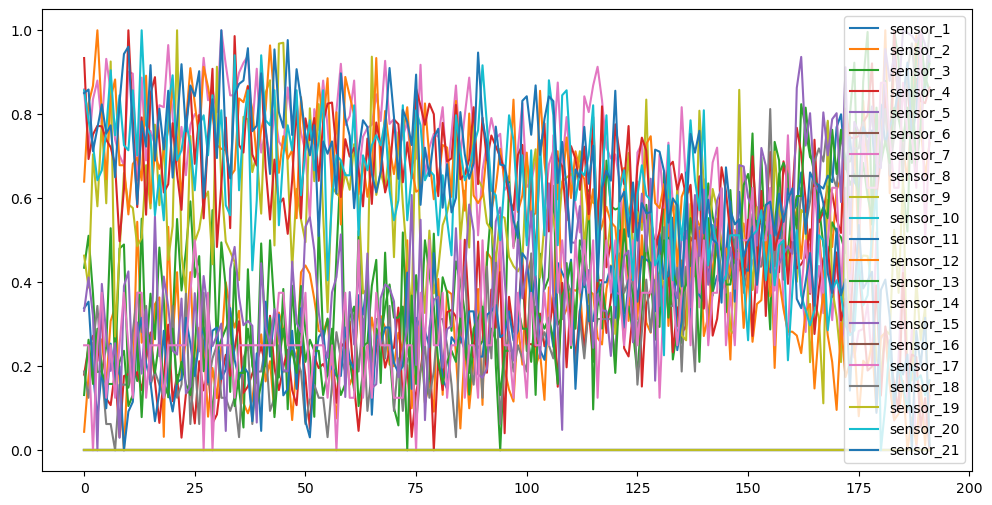

In [73]:
plt.figure(figsize=(12,6))
for col in sensors_only:
    plt.plot(scaled_df[col], label=col)
    plt.legend()
plt.show()

→ Visualizing subset of sensors by plotting them, In the same figure To understand their nature

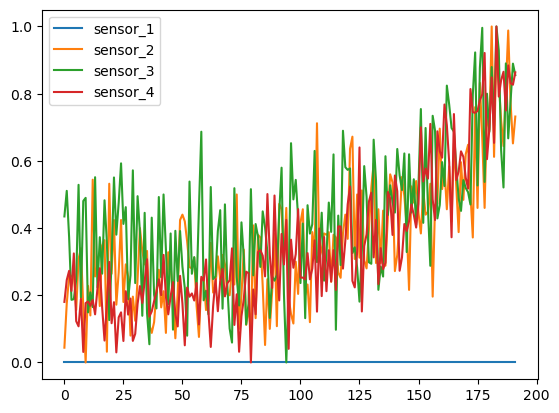

In [74]:
subset = ["sensor_1", "sensor_2", "sensor_3", "sensor_4"]

for col in subset:
    plt.plot(scaled_df[col], label=col)
plt.legend()
plt.show()


Looking at individual sensor features.

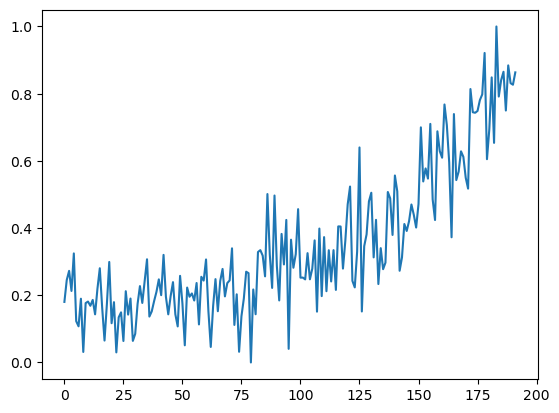

In [75]:
plt.plot(scaled_df["sensor_4"] )  
# Since Feature Cycle - is constant increasing value - So it can be considered as if it's in X axis

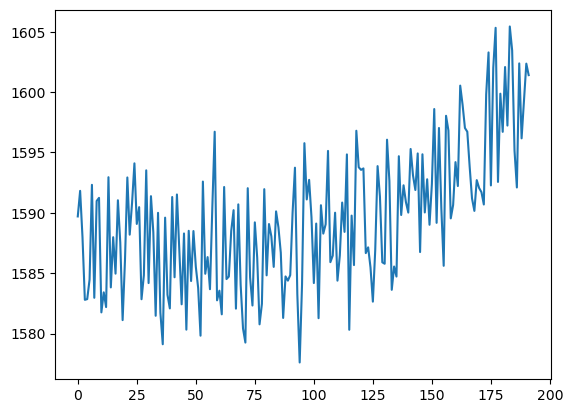

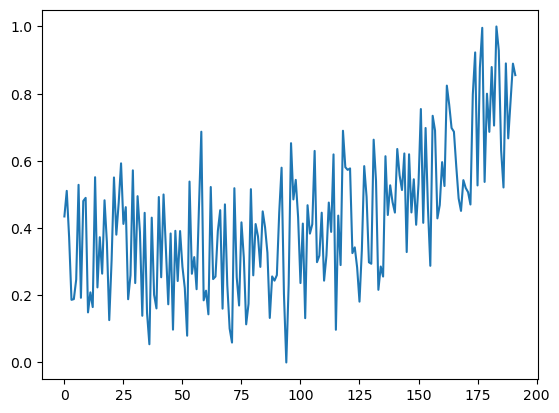

In [76]:
plt.plot(engine_1["sensor_3"])
plt.show()

# OR
 
col = engine_1["sensor_3"]
norm_col = (col - col.min()) / (col.max() - col.min())
plt.plot(norm_col)
plt.show()

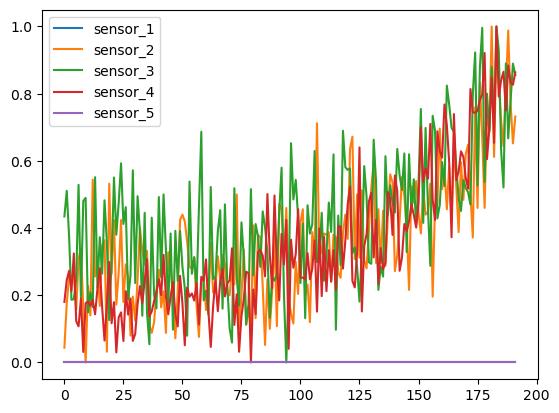

In [77]:
subset = ["sensor_1", "sensor_2", "sensor_3", "sensor_4" , "sensor_5"]

for col in subset:
    plt.plot(scaled_df[col], label=col)
plt.legend()
plt.show()
# OR 
# plt.plot(scaled_df[subset] , label = subset)
# plt.legend()

In [78]:
engine_1[sensors_only]

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,518.67,643.75,1602.38,1422.78,14.62,21.61,551.94,2388.31,9037.91,1.3,...,519.79,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588
188,518.67,644.18,1596.17,1428.01,14.62,21.61,550.70,2388.27,9044.55,1.3,...,519.58,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127
189,518.67,643.64,1599.22,1425.95,14.62,21.61,551.29,2388.29,9040.58,1.3,...,520.04,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675
190,518.67,643.34,1602.36,1425.77,14.62,21.61,550.92,2388.28,9042.76,1.3,...,519.57,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295


Removing the Sensors, which are constant and hence non useful.

In [79]:
# Traversing each column of the scaled data frame we have created 
# And if all values are zero -  Means constant In the original dataset - removing them

constant_sensors = []
for i in scaled_df.columns:
    if((scaled_df[i]== 0).all()):
        constant_sensors.append(i)
constant_sensors
# varying_sensors = [i for i in scaled_df.columns if (scaled_df[i]== 0).all()]

varying_sensors_df= scaled_df.drop(columns=constant_sensors)

In [80]:
varying_sensors_df


,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,0.044,0.434626,0.180277,0.859155,0.18750,0.463380,0.338462,0.639640,0.131579,0.933895,0.332039,0.250,0.857143,0.850490
1,0.176,0.510776,0.245506,0.715962,0.12500,0.387638,0.353846,0.825826,0.263158,0.693423,0.411650,0.250,0.785714,0.858991
2,0.256,0.373204,0.272727,0.835681,0.25000,0.704537,0.184615,0.867868,0.157895,0.752108,0.321036,0.000,0.726190,0.712253
3,0.256,0.186422,0.212892,0.880282,0.34375,0.580922,0.076923,1.000000,0.289474,0.772344,0.000000,0.250,0.642857,0.767141
4,0.264,0.188578,0.324602,0.774648,0.18750,0.783494,0.192308,0.798799,0.184211,0.771332,0.396117,0.375,0.666667,0.823508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,0.816,0.890086,0.749872,0.291080,0.96875,0.167560,0.746154,0.078078,0.684211,0.227993,0.987055,0.750,0.202381,0.000000
188,0.988,0.667026,0.884181,0.000000,0.84375,0.404787,0.807692,0.015015,0.947368,0.221922,0.971521,0.625,0.166667,0.284421
189,0.772,0.776580,0.831279,0.138498,0.90625,0.262951,1.000000,0.153153,1.000000,0.055649,0.997411,1.000,0.178571,0.200887
190,0.652,0.889368,0.826656,0.051643,0.87500,0.340836,0.861538,0.012012,0.868421,0.124115,0.965696,0.500,0.130952,0.315468


In [81]:
max_cycle_per_unit = data.groupby("unit").agg({"cycle":"max"})
max_cycle_per_unit

,cycle
unit,
1,192
2,287
3,179
4,189
5,269
...,...
96,336
97,202
98,156


#### Creating the Target Variable (RUL)

In the training dataset, the full trajectory until failure is available.  
So for each row:

`RUL = maximum cycle of that engine - current cycle`

This gives the target variable used for model training.


In [82]:
data["RUL"] = data.groupby("unit")["cycle"].transform('max')-data['cycle']
data[["unit", "RUL"]]

# In Two Steps 

# data["max_cycle_per_unit"] = data.groupby("unit")["cycle"].transform("max")
# data["RUL"] = data["max_cycle_per_unit"] - data["cycle"]

,unit,RUL
0,1,191
1,1,190
2,1,189
3,1,188
4,1,187
...,...,...
20626,100,4
20627,100,3
20628,100,2
20629,100,1


Checking correlation Features with RUL column.<br>
We're checking which Sensors Columns are associated with RUL values,<br>
hence will be useful For studying degradation patterns

In [83]:
# Checking correlation of sensors with RUL. From the correlation matrix only checking the correlation with the ["RUL"] column

features_other_than_sensors = data.columns.drop(sensors_only)
correlation = data[sensors_only + ['RUL']].corr()['RUL'].abs().sort_values(ascending=False)
# correlation = data.corr()["RUL"].drop(features_other_than_sensors).abs().sort_values(ascending=False)
correlation


# Sort_values() Only works on series and not 2-D dataframes.
# Correlation matrix gives Each column correlation with each other in a 2D Tabular format.

RUL          1.000000
sensor_11    0.696228
sensor_4     0.678948
sensor_12    0.671983
sensor_7     0.657223
sensor_15    0.642667
sensor_21    0.635662
sensor_20    0.629428
sensor_2     0.606484
sensor_17    0.606154
sensor_3     0.584520
sensor_8     0.563968
sensor_13    0.562569
sensor_9     0.390102
sensor_14    0.306769
sensor_6     0.128348
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64

Checking correlation with Different methods And understanding with method which is More suitable for our approach.

METHOD - PEARSON (default)
when relationship is roughly straight-line
when data is numeric and reasonably well-behaved
if one sensor increases steadily as RUL decreases, Pearson is useful.

METHOD - SPEARMAN 
When relationship is monotonic but not linear
when data may not follow a straight-line pattern
Here, The sensor value Changes in a car ho like manner, While also generally increasing or decreasing. Hence, we use this method


In [84]:
# Spearman method for non-linear monotonic Relations.
correlation = data.corr(method='spearman').drop(features_other_than_sensors)['RUL'].abs().sort_values(ascending=False)
correlation

sensor_11    0.718132
sensor_4     0.701771
sensor_12    0.693149
sensor_7     0.678845
sensor_15    0.665905
sensor_21    0.657417
sensor_20    0.653336
sensor_17    0.629397
sensor_2     0.628588
sensor_3     0.605609
sensor_8     0.573864
sensor_13    0.572549
sensor_9     0.322014
sensor_14    0.201792
sensor_6     0.128070
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64

In [85]:
correlation = correlation[correlation>0.5]
correlation

sensor_11    0.718132
sensor_4     0.701771
sensor_12    0.693149
sensor_7     0.678845
sensor_15    0.665905
sensor_21    0.657417
sensor_20    0.653336
sensor_17    0.629397
sensor_2     0.628588
sensor_3     0.605609
sensor_8     0.573864
sensor_13    0.572549
Name: RUL, dtype: float64

In [86]:
selected_sensors = correlation[correlation>0.5].index.tolist()
selected_sensors

['sensor_11',
 'sensor_4',
 'sensor_12',
 'sensor_7',
 'sensor_15',
 'sensor_21',
 'sensor_20',
 'sensor_17',
 'sensor_2',
 'sensor_3',
 'sensor_8',
 'sensor_13']

Now working only with sensors which are `correlated with RUL`

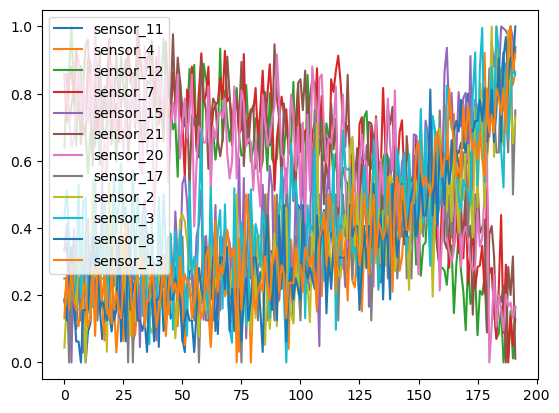

In [87]:
plt.plot(scaled_df[selected_sensors],label = selected_sensors)
plt.legend()
plt.show()
# OR
# for col in selected_sensors:
#     plt.plot(engine_1['cycle'],scaled_df[col], label = col)
# plt.legend()
# plt.show()

Visualising Individual and pair of selected sensors 

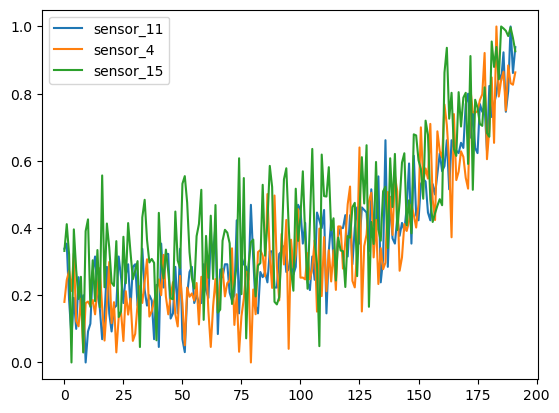

In [88]:
plt.plot(scaled_df['sensor_11'],label = 'sensor_11')
plt.plot(scaled_df['sensor_4'],label = 'sensor_4')
plt.plot(scaled_df['sensor_15'],label = 'sensor_15')
plt.legend()



C:\Users\lenovo\AppData\Local\Temp\ipykernel_21276\781310757.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


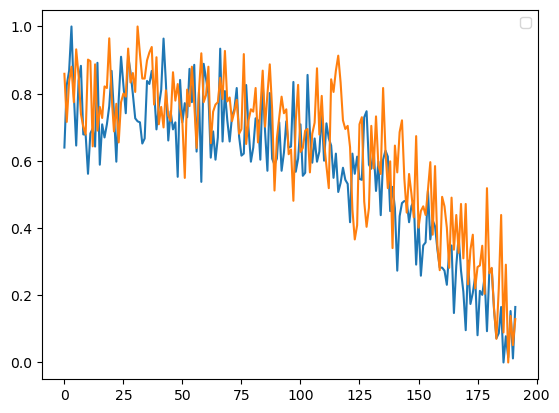

In [89]:
plt.plot(scaled_df['sensor_12'])
plt.plot(scaled_df['sensor_7'])
plt.legend()

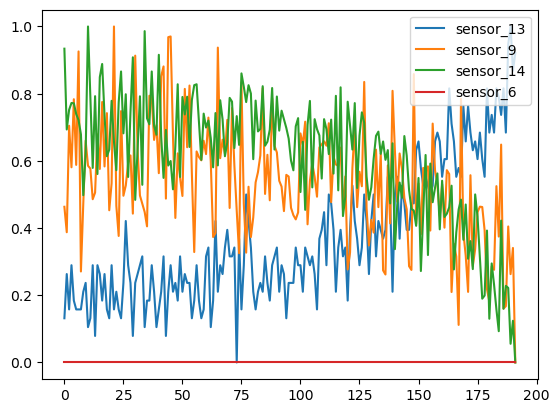

In [90]:
plt.plot(scaled_df['sensor_13'],label = 'sensor_13')
plt.plot(scaled_df['sensor_9'],label = 'sensor_9')
plt.plot(scaled_df['sensor_14'],label = 'sensor_14')
plt.plot(scaled_df['sensor_6'],label = 'sensor_6')
plt.legend()


Plotting a scatter plot to determine whether relationship is linear or non-linear.<br>
The type of relationship between sensors and RUL.<br>
This will further determine `suitable model` for the RUL prediction 

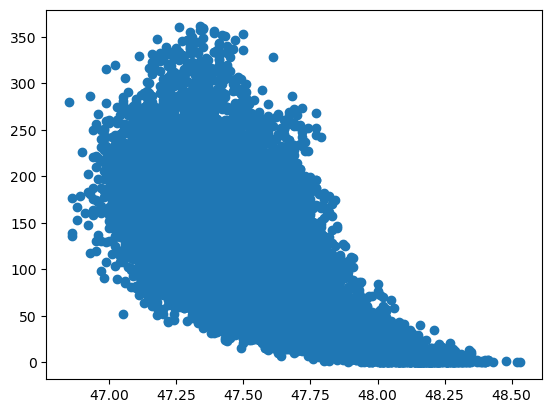

In [91]:
# The plot shows that it is not a single line

plt.scatter(data["sensor_11"], data["RUL"])
# plt.scatter(data["sensor_3"], data["RUL"])
# plt.scatter(data["sensor_7"], data["RUL"])

In [92]:
#  First, we are considering all of the sensors with correlation > 0.5 (Not refining at the moment )
selected_sensors
settings = ['operational setting 1' , 'operational setting 2', 'operational setting 3']
features = [selected_sensors + settings]
X = data[selected_sensors + settings]
Y = data['RUL']

Calculating which sensors Have high correlation Among themselves <br>
1. We are doing that so that we can further take the ratio of the sensors which have moderate correlation with each other - Meaning which show the sensor trend together.<br>
2. Sensors having high correlation with each other Would be conveying same info while the those which don't have any correlation among themselves won't be showing any trend.<br>
3. Taking the Correlated sensors will give us more information and clear sensor trend w.r.t RUL 

In [93]:
correlation_among_sensors = data[selected_sensors].corr()

In [94]:
# sensor_corr = data[selected_sensors].corr()
# Too high or too low correlation is Not useful as The information is either redundant or Not at all from those pairs.
selected_sensors_pairs_having_HighCorrelation= []
cols = correlation_among_sensors.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if abs(correlation_among_sensors.iloc[i, j]) > 0.5:
            selected_sensors_pairs_having_HighCorrelation.append((cols[i], cols[j], correlation_among_sensors.iloc[i, j]))

selected_sensors_pairs_having_HighCorrelation


[('sensor_11', 'sensor_4', np.float64(0.830135696315981)),
 ('sensor_11', 'sensor_12', np.float64(-0.8468835930051095)),
 ('sensor_11', 'sensor_7', np.float64(-0.8228050249957698)),
 ('sensor_11', 'sensor_15', np.float64(0.7809127612290541)),
 ('sensor_11', 'sensor_21', np.float64(-0.7725544629421499)),
 ('sensor_11', 'sensor_20', np.float64(-0.7715096058655173)),
 ('sensor_11', 'sensor_17', np.float64(0.7222963106255637)),
 ('sensor_11', 'sensor_2', np.float64(0.7400200250826926)),
 ('sensor_11', 'sensor_3', np.float64(0.695900151895244)),
 ('sensor_11', 'sensor_8', np.float64(0.7822127696336494)),
 ('sensor_11', 'sensor_13', np.float64(0.780760787176233)),
 ('sensor_4', 'sensor_12', np.float64(-0.815590516105214)),
 ('sensor_4', 'sensor_7', np.float64(-0.7931295615103564)),
 ('sensor_4', 'sensor_15', np.float64(0.7584588237333841)),
 ('sensor_4', 'sensor_21', np.float64(-0.7451931072313168)),
 ('sensor_4', 'sensor_20', np.float64(-0.7480671529345257)),
 ('sensor_4', 'sensor_17', np.f

In [95]:
selected_sensors_pairs_having_ModerateCorrelation = [(a, b, c) for a, b, c in selected_sensors_pairs_having_HighCorrelation if 0.4 <= abs(c) <= 0.7]
selected_sensors_pairs_having_ModerateCorrelation

# Possible pairs of sensors we can take that Convey meaningful information and trend of changes with RUL.

[('sensor_11', 'sensor_3', np.float64(0.695900151895244)),
 ('sensor_4', 'sensor_3', np.float64(0.6784127230560495)),
 ('sensor_12', 'sensor_3', np.float64(-0.680306813169021)),
 ('sensor_7', 'sensor_17', np.float64(-0.6928926302047294)),
 ('sensor_7', 'sensor_3', np.float64(-0.664595307113231)),
 ('sensor_15', 'sensor_17', np.float64(0.6692049306289932)),
 ('sensor_15', 'sensor_2', np.float64(0.6759751834687675)),
 ('sensor_15', 'sensor_3', np.float64(0.6399212019115175)),
 ('sensor_15', 'sensor_13', np.float64(0.6976618546670159)),
 ('sensor_21', 'sensor_20', np.float64(0.6934799722903526)),
 ('sensor_21', 'sensor_17', np.float64(-0.6587097546132161)),
 ('sensor_21', 'sensor_2', np.float64(-0.6680502336445693)),
 ('sensor_21', 'sensor_3', np.float64(-0.633900822083839)),
 ('sensor_21', 'sensor_8', np.float64(-0.6888400311460574)),
 ('sensor_21', 'sensor_13', np.float64(-0.6889476988498029)),
 ('sensor_20', 'sensor_17', np.float64(-0.6510208740940535)),
 ('sensor_20', 'sensor_2', np.f

Determining Among the selected sensors Which have least noise or fluctuations. And shows clear trend.

In [96]:
least_noise_sensors = scaled_df[selected_sensors].std().sort_values().tolist
least_noise_sensors = scaled_df[selected_sensors].std().sort_values().index.tolist()
least_noise_sensors


['sensor_17',
 'sensor_21',
 'sensor_2',
 'sensor_20',
 'sensor_13',
 'sensor_11',
 'sensor_3',
 'sensor_7',
 'sensor_4',
 'sensor_15',
 'sensor_8',
 'sensor_12']

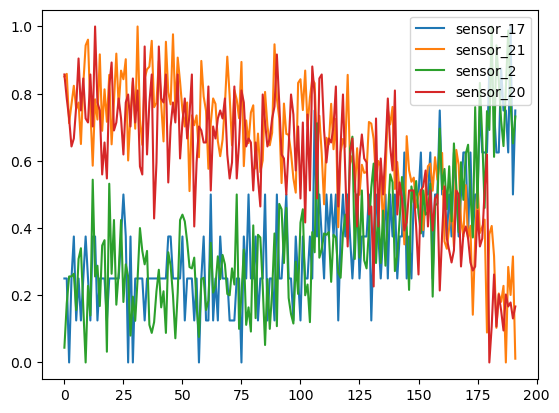

In [97]:
plt.plot(scaled_df['sensor_17'], label = "sensor_17")
plt.plot(scaled_df['sensor_21'], label = "sensor_21")
plt.plot(scaled_df['sensor_2'], label = "sensor_2")
plt.plot(scaled_df['sensor_20'], label = "sensor_20")
plt.legend()

Now takeing those sensor_pairs which have - <br> 
1. High correlation with RUL <br> 
2. Moderate correlation with each other and <br>
3. Have least fluctuation or noise.

NOTE: If we are testing from a different Dataset. Then we have to make sure that these senor_pairs individually exist in that test dataset as well.

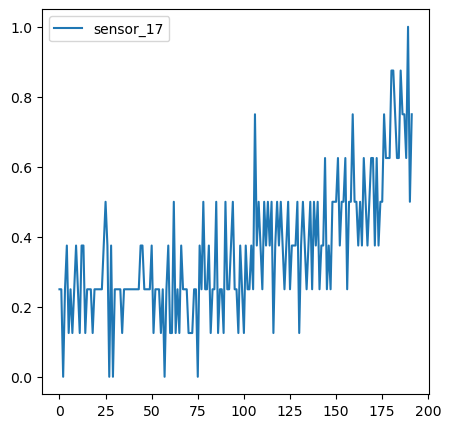

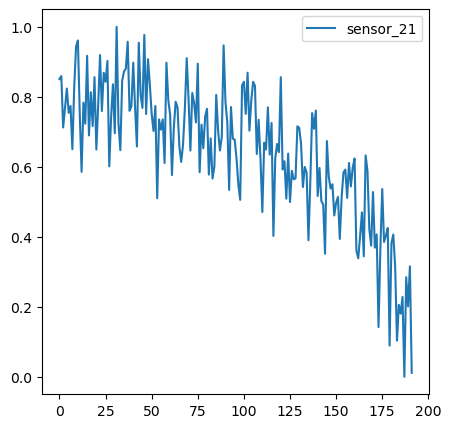

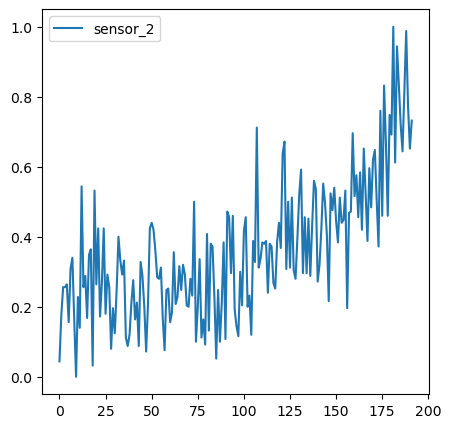

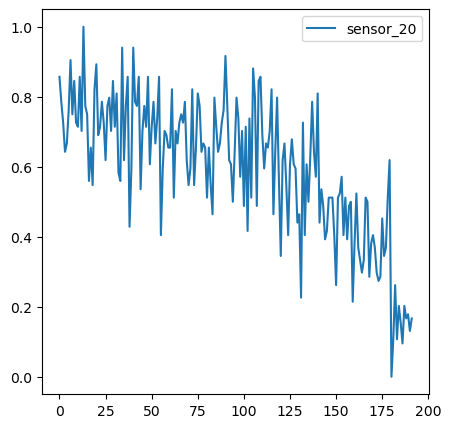

In [98]:
# for col in least_fluc_sensors:
for col in ['sensor_17', 'sensor_21', 'sensor_2', 'sensor_20']:
    plt.figure(figsize=(5,5))
    plt.plot(scaled_df[col], label = col)
    plt.legend()
#  Is there any way you can Make them shown in a grid ?


In [99]:

settings = ['operational setting 1' , 'operational setting 2', 'operational setting 3']
features = [selected_sensors + settings ]
X = data[selected_sensors + settings]
Y = data['RUL']

# When splitting the trainging dataset for training and testing.
from sklearn.model_selection import train_test_split    
x_train, x_test , y_train , y_test = train_test_split( X , Y ,test_size =0.2 , random_state = 42)


from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)


from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


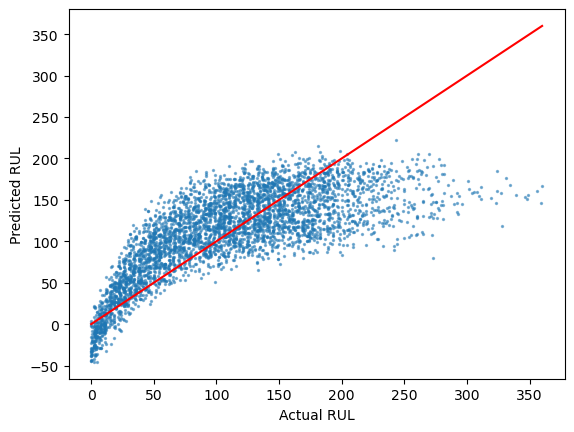

In [100]:
y_pred = model.predict(x_test)

#  Visualise the Predicted values of RUL from actual values given in the Training Dataset.
plt.scatter(y_test, y_pred, s =2, alpha=0.5 ) # The plot will be between the Y_test values (original) versus the Y_predicted from X test values
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')

In [101]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
import numpy as np

mae= mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(mae)
print(mse)
print(r2)

34.78226473233332
2050.8589217797917
0.5511160238495878


Using a separate `Test Dataset` To evaluate the model results

In [102]:
data_test = pd.read_csv("E:\Data Science Project\Telemetry Anomaly\cleaned_datatest001.csv")
test001 = data_test

In [103]:
# If we are Testing features to evaluate The model Then take those sensor features, which are also available in the test data set.
# These features are NOT available in the test dataset.

data['ratio_of_2_and_20'] = data['sensor_2']/ data['sensor_20']
data['ratio_of_17_and_21'] = data['sensor_17']/ data['sensor_21']

In [104]:
train001 = data_train
test001 = data_test

# Choosing the created feature in both Training and Testing. 
test001['ratio_of_11_and_3'] = test001['sensor_11'] / test001['sensor_3']
test001['ratio_of_7_and_4'] = test001['sensor_7'] / test001['sensor_4']

train001['ratio_of_11_and_3'] = train001['sensor_11'] / train001['sensor_3']
train001['ratio_of_7_and_4'] = train001['sensor_7'] / train001['sensor_4']

features= selected_sensors + settings + ['ratio_of_11_and_3', 'ratio_of_7_and_4']

x_train = train001[features]
y_train = train001['RUL']

# Choosing only the last row Our last operational cycle. Because RUL Predicted will be from here till the end.
test_last = test001.groupby('unit').last().reset_index()
x_test = test_last[features]

rul_test = pd.read_csv("E:\Data Science Project\Telemetry Anomaly\Telemetry Dataset - CMaps\RUL_FD001.txt", sep=r"\s+", header=None).iloc[:, 0]

# Scaling a features
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)


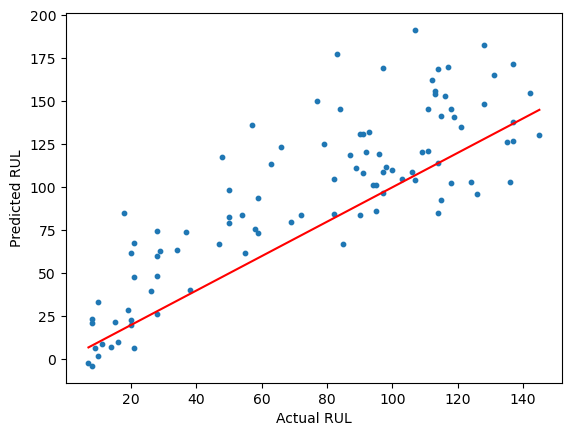

In [105]:
plt.scatter(rul_test, y_pred, s=10)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.plot([rul_test.min(), rul_test.max()], [rul_test.min(), rul_test.max()], color='red')
plt.show()


In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
import numpy as np

mae= mean_absolute_error(rul_test, y_pred)
mse = mean_squared_error(rul_test, y_pred)
r2 = r2_score(rul_test, y_pred)
print(mae)
print(mse)
print(r2)

26.01843867429678
1116.5784111311334
0.3534089596972849
